<p style="color:#FFF; background:#800000; padding:12px; font-size:20px; font-style:italic; text-align:center">
<span style="width:49%; display:inline-block; text-align:left">BAILLET Benjamin</span>
<span style="width:49%; display:inline-block; text-align:right">Computational Finance</span>
<span style="font-size:48px; font-style:normal"><b>Projet 2: Stratégie d'investissement</b></span><br>
<span style="width:49%; display:inline-block; text-align:left">DJEIGO Yannick</span>
<span style="width:49%; display:inline-block; text-align:right">Master IREF-FQA</span></p>

<h2 style="padding:16px; color:#FFF; background:#800000"> Stratégie 1: Moyenne Mobile (Moving Average)</h2>

## Objectif du projet 

Modélisation d'une stratégie d'investissement en Python sous Jupyter 

In [110]:
# Import des packages 
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt # package pour faire des graphiques

import random 

from matplotlib.dates import DateFormatter

import warnings
warnings.filterwarnings('ignore')

## A - Mise en place de la stratégie d'investissement

### 1) Import des données

#### Récupération des données d'un CSV

In [113]:
# Charger les données historiques sde la composition l'Euro Stoxx 50 (grâce à un fichier .csv)
df = pd.read_csv("compo_eurostoxx_data.csv", sep=';', index_col='Date', parse_dates=['Date'], date_format='%d/%m/%Y')

# Comprendre le jeu de données 
df_T = pd.DataFrame(df.dtypes).rename(columns={0: 'Type de données'})
df_T.head(10)

,Type de données
ADS GY Equity,object
AI FP Equity,object
AIR FP Equity,object
ALV GY Equity,object
ABI BB Equity,object
ASML NA Equity,object
CS FP Equity,object
BBVA SM Equity,object
SAN SM Equity,object
BAS GY Equity,object


In [115]:
# mise en évidence de 5 premières valeurs des données brutes pour chaque action
print(df.head())

           ADS GY Equity AI FP Equity AIR FP Equity ALV GY Equity  \
Date                                                                
2018-12-31         182,4        89,63         83,96        175,14   
2019-01-01         182,4        89,63         83,96        175,14   
2019-01-02         184,4        87,69         84,17           175   
2019-01-03        183,95        86,07         81,21        173,16   
2019-01-04        191,05        88,47         85,12        177,36   

           ABI BB Equity ASML NA Equity CS FP Equity BBVA SM Equity  \
Date                                                                  
2018-12-31          57,7         137,16        18,86           4,64   
2019-01-01          57,7         137,16        18,86           4,64   
2019-01-02         57,47         137,46        18,81           4,66   
2019-01-03         58,17         131,74        18,65           4,68   
2019-01-04         60,54          133,7        19,24           4,85   

           SAN SM 

#### Retraitement du jeu de données

In [118]:
df = df.apply(lambda col: col.apply(lambda x: pd.to_numeric(x.replace(",", "."), errors='coerce')))

# Comprendre le jeu de données 
df_T = pd.DataFrame(df.dtypes).rename(columns={0: 'Type de données'})
df_T.head(10)

,Type de données
ADS GY Equity,float64
AI FP Equity,float64
AIR FP Equity,float64
ALV GY Equity,float64
ABI BB Equity,float64
ASML NA Equity,float64
CS FP Equity,float64
BBVA SM Equity,float64
SAN SM Equity,float64
BAS GY Equity,float64


In [119]:
# mise en évidence de 5 premières valeurs des données retraitées pour chaque action
print(df.head())

            ADS GY Equity  AI FP Equity  AIR FP Equity  ALV GY Equity  \
Date                                                                    
2018-12-31         182.40         89.63          83.96         175.14   
2019-01-01         182.40         89.63          83.96         175.14   
2019-01-02         184.40         87.69          84.17         175.00   
2019-01-03         183.95         86.07          81.21         173.16   
2019-01-04         191.05         88.47          85.12         177.36   

            ABI BB Equity  ASML NA Equity  CS FP Equity  BBVA SM Equity  \
Date                                                                      
2018-12-31          57.70          137.16         18.86            4.64   
2019-01-01          57.70          137.16         18.86            4.64   
2019-01-02          57.47          137.46         18.81            4.66   
2019-01-03          58.17          131.74         18.65            4.68   
2019-01-04          60.54          133

### 2) Définition et mise en place de la stratégie d'investissement

La stratégie d'investissement choisie est la suivante : **Moyenne Mobile**

La stratégie d'investissement adoptée repose sur l'utilisation de deux moyennes mobiles, une **moyenne mobile courte** et une **moyenne mobile longue**, pour identifier les opportunités d'achat et de vente. Ces moyennes mobiles permettent de capter les tendances à court et à long terme des prix des actions, en générant des signaux basés sur leurs croisements.

#### Règles de la stratégie
- **Signal d'achat :**  
  Lorsque la **moyenne mobile courte (50 jours)** croise **à la hausse** la **moyenne mobile longue (200 jours)**, cela indique une tendance haussière. Un ordre d'achat est alors déclenché pour tirer parti de cette dynamique positive.

- **Signal de vente :**  
  Lorsque la **moyenne mobile courte (50 jours)** croise **à la baisse** la **moyenne mobile longue (200 jours)**, cela indique une tendance baissière. Un ordre de vente est alors déclenché pour protéger le portefeuille contre une éventuelle baisse des prix.

Ces signaux sont représentés graphiquement, offrant une visualisation claire des moments où la stratégie recommande une action.


#### Sélection des actions
La stratégie est appliquée aux actions de l'**Eurostoxx 50**, un indice regroupant les 50 plus grandes entreprises européennes en termes de capitalisation boursière. Ce choix garantit que les actions utilisées dans la stratégie sont **très liquides**, ce qui signifie qu'elles peuvent être achetées et vendues rapidement sans impact significatif sur leur prix. Cela réduit les coûts liés au slippage (écart entre le prix attendu et le prix réel de l'exécution) et améliore l'exécution des ordres.

#### Backtesting de la stratégie
- **Période de backtesting :**  
  La stratégie est testée sur les données historiques de la période allant du **31/12/2018 au 31/12/2022**. Cette étape permet d'évaluer la pertinence et la robustesse de la stratégie dans des conditions de marché variées.

- **Évaluation de la performance :**  
  Les performances de la stratégie seront ensuite étudiées sur l'année **2023**, afin de vérifier sa capacité à générer des rendements positifs sur une période hors échantillon.

#### Avantages de cette approche
1. **Approche systématique :**  
   Les signaux d'achat et de vente sont générés de manière claire et non subjective, ce qui réduit les biais émotionnels.
2. **Gestion des risques :**  
   La stratégie s'ajuste automatiquement aux conditions de marché en sortant des positions lorsque les tendances baissières sont détectées.
3. **Liquidité garantie :**  
   L'utilisation des actions de l'Eurostoxx 50 élimine les risques liés à l'illiquidité.



#### Calculer la moyenne mobile de chaque action du 31/12/2018 à 31/12/2022

In [123]:
# Tout d'abord, il faut redéfinir notre plage de données 
# Créons un DataFrame pour le Backtesting
date_debut = '2018-12-31'
date_fin = '2022-12-30'

# Filtrez les données en fonction de la plage de dates
df_backtesting = df.loc[date_debut:date_fin]
print(df_backtesting)

            ADS GY Equity  AI FP Equity  AIR FP Equity  ALV GY Equity  \
Date                                                                    
2018-12-31         182.40         89.63          83.96         175.14   
2019-01-01         182.40         89.63          83.96         175.14   
2019-01-02         184.40         87.69          84.17         175.00   
2019-01-03         183.95         86.07          81.21         173.16   
2019-01-04         191.05         88.47          85.12         177.36   
...                   ...           ...            ...            ...   
2022-12-23         125.86        133.70         111.74         202.20   
2022-12-27         126.34        133.92         112.82         203.05   
2022-12-28         125.78        133.36         111.62         202.15   
2022-12-29         128.38        134.70         112.02         203.70   
2022-12-30         127.46        132.40         111.02         200.90   

            ABI BB Equity  ASML NA Equity  CS FP E

#### Sélectionner les actions à acheter ou vendre en fonction des moyennes mobiles

Pour ce faire, on doit faire un Dataframe de valeurs binaires, en affectant 0 lorsque la condition n'est pas respectée et 1 lorsque la condition l'est.

Les périodes de 50 jours et 200 jours sont des standards en finance :

- **50 jours** : Reflète la tendance à court terme (2 mois environ). Utile pour repérer les mouvements récents.
- **200 jours** : Montre la tendance à long terme (presque un an). Sert à évaluer la direction générale du marché.
 
Le croisement de ces moyennes aide à détecter des signaux d'achat ou de vente :

- Croisement haussier (50 dépasse 200) : **Signal d'achat**
- Croisement baissier (50 passe sous 200) : **Signal de vente**
  
Ces périodes sont populaires car elles équilibrent précision et simplicité.

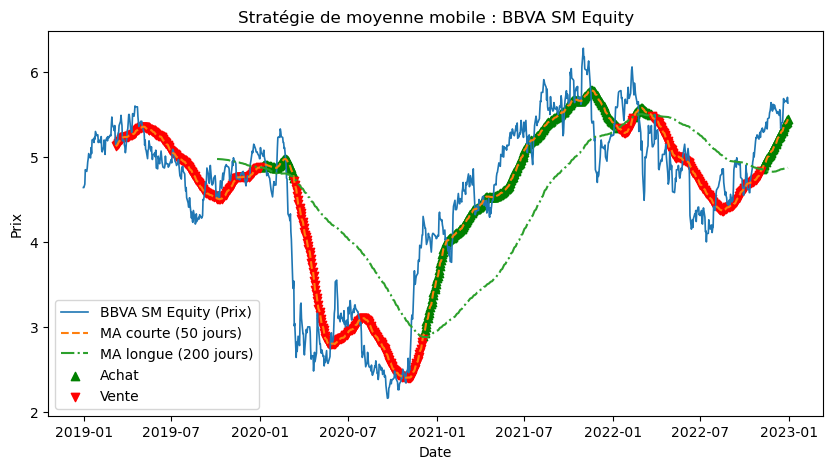

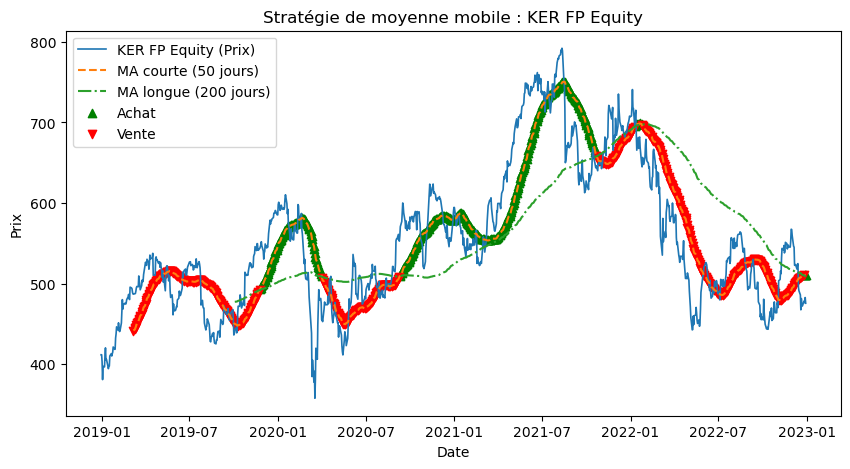

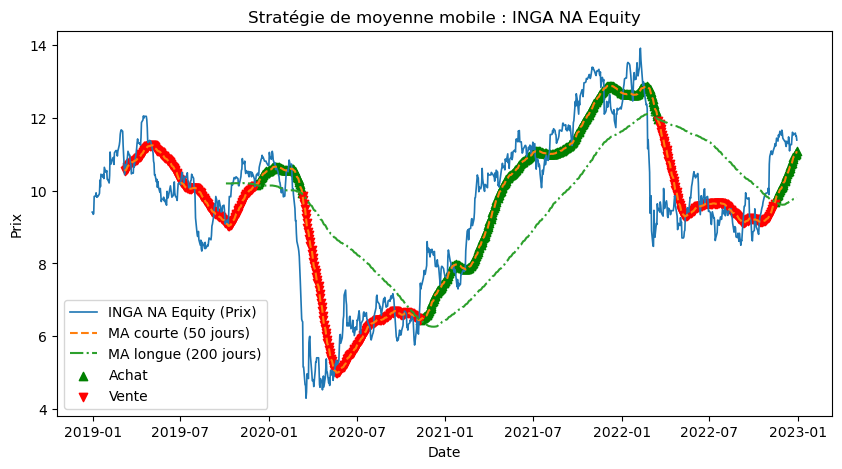

In [126]:
# Paramètres des moyennes mobiles
short_window = 50  # Fenêtre pour la moyenne mobile courte (50 jours)
long_window = 200  # Fenêtre pour la moyenne mobile longue (200 jours)

# Calcul des moyennes mobiles pour chaque action
short_ma = df_backtesting.rolling(window=short_window).mean()  # Moyenne mobile courte
long_ma = df_backtesting.rolling(window=long_window).mean()  # Moyenne mobile longue

# Génération des signaux d'achat (1) ou de vente (0) basés sur la comparaison des moyennes mobiles
signals = (short_ma > long_ma).astype(int)  # Signaux = 1 si MA courte > MA longue, sinon 0

# Sélectionner trois actions aléatoires parmi celles présentes dans le DataFrame pour les graphiques
selected_actions = random.sample(list(df_backtesting.columns), 3)  # 3 actions au hasard

# Calcul et affichage des graphiques pour chaque action sélectionnée
for action in selected_actions:
    plt.figure(figsize=(10, 5))  # Créer une nouvelle figure pour chaque graphique
    plt.plot(df_backtesting[action], label=f'{action} (Prix)', linewidth=1.2)  # Tracer les prix de l'action
    plt.plot(short_ma[action], label=f'MA courte ({short_window} jours)', linestyle='--')  # Tracer la MA courte
    plt.plot(long_ma[action], label=f'MA longue ({long_window} jours)', linestyle='-.')  # Tracer la MA longue
    plt.scatter(df_backtesting.index[signals[action] == 1], short_ma[action][signals[action] == 1], color='g', marker='^', label='Achat')  # Signaux d'achat
    plt.scatter(df_backtesting.index[signals[action] == 0], short_ma[action][signals[action] == 0], color='r', marker='v', label='Vente')  # Signaux de vente
    plt.title(f"Stratégie de moyenne mobile : {action}")  # Titre du graphique
    plt.xlabel("Date")  # Label de l'axe des X
    plt.ylabel("Prix")  # Label de l'axe des Y
    plt.legend()  # Ajouter une légende
    plt.show()  # Afficher le graphique

# Filtrer les résultats en ignorant les 200 premiers jours (phase d'apprentissage des moyennes mobiles)
df_results = signals.iloc[200:]  # Prendre les données à partir du 201ème jour
df_results.columns = [col.replace('_Signal', '') for col in df_results.columns]  # Renommer les colonnes pour supprimer le suffixe '_Signal'


#### Contrôle de cohérence

Pour garantir la validité de notre stratégie d'investissement, nous allons vérifier qu'à chaque date entre 2019 et 2022, au moins une action de l'Eurostoxx 50 respecte la condition définie.

La stratégie repose sur un principe simple :

- Investir dans une action uniquement lorsque la moyenne mobile courte (court terme) dépasse la moyenne mobile longue (long terme).
- Sinon, aucune position n’est prise pour cette action.

Cela signifie qu’il peut exister des périodes où aucune action ne respecte la condition d’investissement. Dans ces moments, aucune position ne serait prise sur le marché.

Cas particulier : périodes sans positions

Si, lors de la phase de backtesting, nous détectons qu'il existe des dates où aucune action ne respecte la condition, la stratégie suppose d’investir 100 % du portefeuille dans une stratégie sans risque (par exemple, un actif sans risque comme des obligations d’État ou un fonds monétaire).

Cette approche garantit :

- Une gestion prudente du portefeuille.
- Une optimisation du rendement en limitant l’exposition au risque durant les périodes d’incertitude.


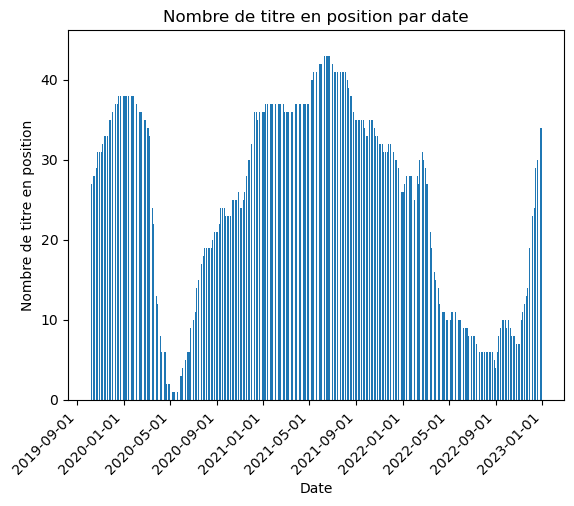

844

In [128]:
# Contrôle condition
df_check = pd.DataFrame({'NB_POS': df_results.sum(axis=1)})

# Visualisation graphique
from matplotlib.dates import DateFormatter

fig, ax = plt.subplots()
bars = ax.bar(df_check.index, df_check['NB_POS'])

# Incliner les étiquettes d'axe pour une meilleure lisibilité
ax.xaxis_date()
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Ajouter des étiquettes et un titre
plt.xlabel('Date')
plt.ylabel('Nombre de titre en position')
plt.title('Nombre de titre en position par date')

# Afficher le graphique
plt.show()

# Combien de dates ne respectent pas la condition
len(df_check[df_check == 0])

Ce qui est intéressant avec cette vue, c'est que nous pourrons voir les grands phénomènes de marché qui ont eu un impact global sur les marchés.

Comme par exemple :

- Mars 2020 => COVID-19
- Février 2022 => Guerre en Ukraine 
A chacun de ces dates, nous pouvons voir qu'il y a une volatilité généralisée des marchés.

Cependant, il existe des moments au cours de la période de test où notre stratégie ne nous fait investir sur aucun titre de l'Eurostoxx 50. Donc il nous faut ajouter un taux sans risque. Un taux sur laquelle la stratégie investira si la condition de 30% de volatilité minimum n'est pas respectée.

Pour se faire, nous allons récupérer les données de l'Euribor 6M.

In [130]:
# Récupération de l'historique de l'EURIBOR 6M (c'est un taux annuel)
euribor_6M = pd.read_csv("euribor6M_data.csv", sep=';', index_col = 'Date', date_parser=lambda x: pd.to_datetime(x, format='%d/%m/%Y'))

# Retraitement du jeu de données
euribor_6M = euribor_6M.applymap(lambda x: pd.to_numeric(x.replace(",", "."), errors='coerce'))

# Visualisation de l'EURIBOR 6M
print(euribor_6M.head())

# Calculons la performance quotidienne de l'EURIBOR 6M => l'EURIBOR est un taux, il suffit de calculer le gain d'un journée de détention de ce taux
daily_Euribor = euribor_6M['EUR006M Index'].apply(lambda x: (1+x)**(1/365)-1)
print(daily_Euribor.head())

            EUR006M Index
Date                     
2018-12-31         -0.237
2019-01-02         -0.238
2019-01-03         -0.237
2019-01-04         -0.237
2019-01-07         -0.236
Date
2018-12-31   -0.000741
2019-01-02   -0.000744
2019-01-03   -0.000741
2019-01-04   -0.000741
2019-01-07   -0.000737
Name: EUR006M Index, dtype: float64


#### Affecter des poids à chaque action sélectionnée

Pour calculer, le poids alloué à chaque action respectant la stratégie, nous choisissions de prendre des poids équipondérés. Autrement dit, le poids de sélection est égal à 1 sur le nombre d'action respectant la stratégie à une date. 

De plus, il faut prendre en compte, le cas où aucune action respecte les conditions de sélection (la moyenne mobile longue est supérieure la moyenne mobile courte). Pour palier à cela, nous allons 100% de notre position au taux sans risque. 

In [133]:
# Ajout de la colonne des besoins de l'EURIBOR 6M
df_check['EUR006M Index'] = df_check['NB_POS'].apply(lambda x: 0 if x > 0 else 1)

# Jointure de la selection des actions avec la colonne des moments où la sélection a été trop sélectif
final_selection = pd.merge(df_results, df_check['EUR006M Index'], on='Date')
final_selection

,ADS GY Equity,AI FP Equity,AIR FP Equity,ALV GY Equity,ABI BB Equity,ASML NA Equity,CS FP Equity,BBVA SM Equity,SAN SM Equity,BAS GY Equity,...,RI FP Equity,SAF FP Equity,SAN FP Equity,SAP GY Equity,SU FP Equity,SIE GY Equity,TTE FP Equity,DG FP Equity,VOW3 GY Equity,EUR006M Index
Date,,,,,,,,,,,,,,,,,,,,,
2019-10-07,1,1,1,1,1,1,0,0,0,0,...,1,1,1,1,1,0,0,1,1,0
2019-10-08,1,1,1,1,1,1,0,0,0,0,...,1,1,1,1,1,0,0,1,1,0
2019-10-09,1,1,1,1,1,1,0,0,0,0,...,1,1,1,1,1,0,0,1,1,0
2019-10-10,1,1,1,1,1,1,0,0,0,0,...,1,1,1,1,1,0,0,1,1,0
2019-10-11,1,1,1,1,1,1,0,0,0,0,...,1,1,1,1,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-23,0,0,1,1,1,1,1,1,0,1,...,0,1,0,1,1,1,1,1,0,0
2022-12-27,0,0,1,1,1,1,1,1,1,1,...,0,1,0,1,1,1,1,1,0,0
2022-12-28,0,1,1,1,1,1,1,1,1,1,...,0,1,0,1,1,1,1,1,0,0


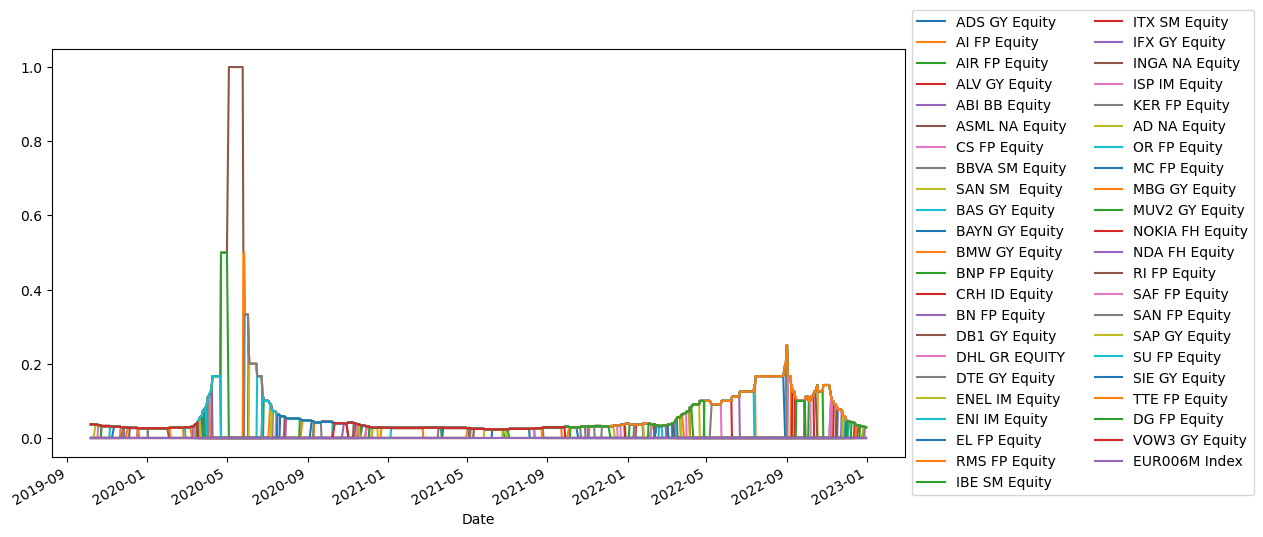

In [134]:
# Ensuite nettoyage du jeu de données 
# la méthode fillna(0) pour remplacer les NaN résultant des valeurs non remplacées par des zéros.
weights = final_selection.fillna(0)

# Calcul des allocations 
# la dernière étape calcule les poids normalisés pour chaque ligne.
weights = weights.apply(lambda x: x / x.sum(), axis=1) 

# Plot avec légende à droite du graphique
ax = weights.plot(figsize=(11, 6))
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2)  # Légende sur deux colonnes

plt.show()

#### Calculer la performance de la stratégie

Ci-dessous nous assurons d'avoir l'ensemble des informations et dans la bonne dimension.

In [136]:
# calculer les rentabilités journalières
daily_returns = df_backtesting.pct_change(periods=1).dropna()

# nous nous assurons que les dataframes soient bien triés
daily_returns.sort_index(ascending=True, inplace=True)
weights.sort_index(ascending=True, inplace=True)

# Nous devons joindre les données daily_euribor avec les daily_returns
final_returns = pd.merge(daily_returns, daily_Euribor, on='Date')

# on s'assure que le dataframe Weight fait la bonne taille
final_returns = final_returns.loc[final_selection.index[0]:final_selection.index[-1]]
weights = weights.loc[final_selection.index[0]:final_selection.index[-1]]

#### Calcul des contributions

Une fois que nous avons filtrer notre jeu de données, calculer les poids d'allocation et générer le performance quotidienne, il nous faut calculer nos contributions à la performance de chaque position à chaque date. 

In [138]:
# Nous multiplions les poids journaliers par les rendements journaliers ainsi nous obtenons les contributions à la performance
strategy_returns = final_returns * weights

# la méthode fillna(0) pour remplacer les NaN résultant des valeurs non remplacées par des zéros.
strategy_returns = strategy_returns.fillna(0)

# La somme des contributions à la performance des actions allouées donne la contribution journalière de la position  
strategy_returns = strategy_returns.sum(axis=1)

strategy_returns.iloc[0] = 0 # nous forçons les premières contributions à la performance à 0 (le premier jour nous ne profitons pas de la performance du jour)


### 3) Résultat sur la période de la stratégie

In [141]:
# Calcul des performances cumulées
cumulative_return = pd.DataFrame((1 + strategy_returns).cumprod()*100, columns = ['MM'])

print(cumulative_return)

                    MM
Date                  
2019-10-07  100.000000
2019-10-08   99.156591
2019-10-09  100.220427
2019-10-10  100.823175
2019-10-11  102.411585
...                ...
2022-12-23  127.882047
2022-12-27  128.427903
2022-12-28  127.681432
2022-12-29  128.778734
2022-12-30  127.082011

[844 rows x 1 columns]


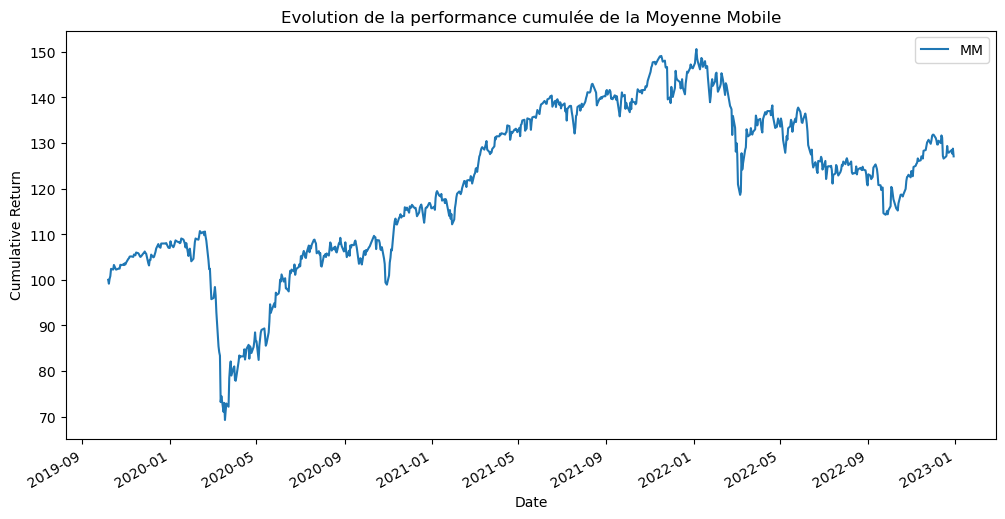

In [144]:
# graphique de l'évolution de la performance cumulée
cumulative_return.plot(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Evolution de la performance cumulée de la Moyenne Mobile")
plt.show()

## B - Comparaison au SX5E

Pour vérifier la performance de notre stratégie d'investissement, nous allons comparer réaliser sur la période de backtesting face à celle de l'Eurostoxx.

### 1) Import des données de SX5E

In [147]:
df = pd.read_csv("eurostoxx50_data.csv", sep=';', index_col = 'Date', date_parser=lambda x: pd.to_datetime(x, format='%d/%m/%Y'))
df = df.applymap(lambda x: pd.to_numeric(x.replace(",", "."), errors='coerce'))
print(df)

            SX5E Index
Date                  
2018-12-31     3001.42
2019-01-02     2993.18
2019-01-03     2954.66
2019-01-04     3041.85
2019-01-07     3033.64
...                ...
2023-12-07     4473.77
2023-12-08     4523.31
2023-12-11     4540.19
2023-12-12     4536.61
2023-12-13     4543.66

[1276 rows x 1 columns]


### 2) Calcul des Performances cumulées SX5E sur la période

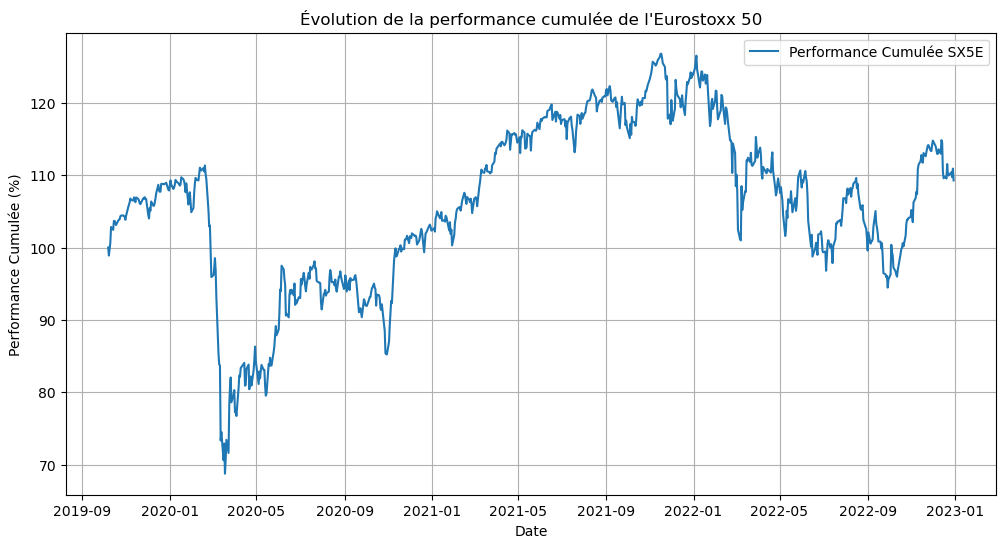

In [152]:
# Calcul des rentabilités journalières de l'Eurostoxx 50
daily_returns_SX5E = df.pct_change().fillna(0)

# Restriction des données à la période d'intérêt
daily_returns_SX5E = daily_returns_SX5E.loc[final_returns.index]

# Forcer la première valeur de rentabilité journalière à 0
daily_returns_SX5E.iloc[0] = 0

# Calcul de la performance cumulée de l'Eurostoxx 50
cumulative_return_SX5E = (1 + daily_returns_SX5E).cumprod() * 100

# Graphique de l'évolution de la performance cumulée
plt.figure(figsize=(12, 6))
plt.plot(cumulative_return_SX5E, label="Performance Cumulée SX5E", linewidth=1.5)
plt.xlabel("Date")
plt.ylabel("Performance Cumulée (%)")
plt.title("Évolution de la performance cumulée de l'Eurostoxx 50")
plt.legend()
plt.grid()
plt.show()


### 3) Stratégie vs Eurostoxx 50

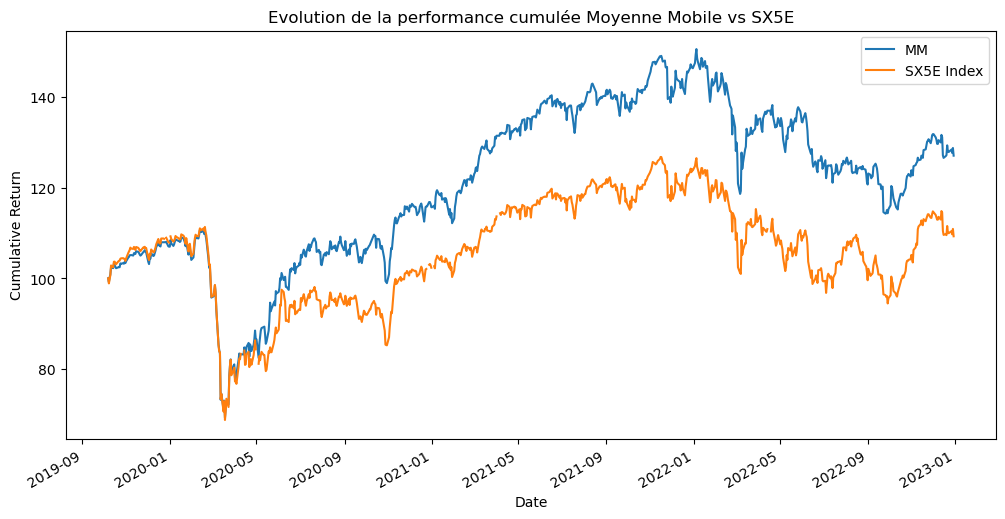

In [156]:
# Création d'un dataframe contenant les 2 valeurs
Compare = cumulative_return.join(cumulative_return_SX5E)

# graphique de l'évolution de la performance cumulée du SX5E
Compare.plot(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Evolution de la performance cumulée Moyenne Mobile vs SX5E")
plt.show()

En analysant la performance de la stratégie de moyenne mobile par rapport à l'Eurostoxx 50 (**SX5E**), nous constatons que la stratégie commence à **surperformer l'indice dès mai 2020 environ** et maintient cette surperformance tout au long de la période de backtesting, jusqu'à **2023**.

#### 1. **2019-2020 : Sous-performance initiale, mais surperformance ensuite**
   - Pendant la période **2019-2020**, la stratégie sous-performe l'indice, notamment durant la crise du **Covid-19**. Cette sous-performance est due à la forte volatilité des marchés, où les signaux de la stratégie n'ont pas été aussi réactifs.
   - **Dès mai 2020**, la stratégie commence à surperformer l'indice Eurostoxx 50. Cela peut être expliqué par la phase de reprise du marché, où la stratégie capte mieux les tendances haussières. Cela indique que notre stratégie a bien capturé les tendances haussières tout en évitant, dans une certaine mesure, les mouvements baissiers.
   - Pendant le creux de 2020, la stratégie MM a subi une baisse significative, mais elle a récupéré plus rapidement que l'indice SX5E.
Cela montre que notre approche est réactive aux retournements de tendance.

#### 2. **2021 : Surperformance continue**
   - En 2021, qui a été une année de forte reprise économique, la stratégie continue de surpasser l'indice, profitant d'une tendance haussière soutenue.

#### 3. **2022-2023 : Surperformance maintenue**
   - La stratégie a continué à surpasser l'indice tout au long de **2022 et 2023**, consolidant ainsi son efficacité durant ces années. Ce phénomène montre que la stratégie fonctionne bien lorsque le marché suit une tendance haussière.
   - On remarque que la stratégie MM a connu une baisse dans la seconde moitié de 2022, mais reste au-dessus de l'indice SX5E. Cette sous-performance relative pourrait être due à une période de marché latéral, où les moyennes mobiles produisent souvent des faux signaux.
     
#### 4. **Comportement général de la stratégie**
   - En règle générale, la stratégie **gagne davantage dans les phases haussières** et perd plus lors des baisses brusques, comme observé pendant le **Covid-19** en 2020. Elle capture bien les tendances positives, mais pourrait être vulnérable lors des retournements rapides ou des baisses soudaines.

### Conclusion 

La stratégie de **moyenne mobile** a montré une **surperformance** par rapport à l'Eurostoxx 50 **dès mai 2020**, et cette surperformance s'est maintenue en **2021, 2022 et 2023**. La stratégie semble particulièrement performante dans un marché **haussier ou stable**, mais pourrait être améliorée pour mieux gérer les **périodes de volatilité élevée ou de baisses soudaines**.


## C - Simulation de la stratégie d'investissement

Maintenant que nous avons testé sur 3 ans notre stratégie d'investissement, il nous faut la simuler sur l'année 2023. L'objectif est de savoir si notre stratégie est tout aussi performante que sur les 3 années précédentes. 

### 1) Récupération les données sur 2023

In [162]:
df = pd.read_csv("compo_eurostoxx_data.csv", sep=';', index_col='Date', parse_dates=['Date'], date_format='%d/%m/%Y')
df = df.apply(lambda col: col.apply(lambda x: pd.to_numeric(x.replace(",", "."), errors='coerce')) if col.dtype == 'object' else col)

# Créons un DataFrame pour la simulation au quotidien (l'application de notre Backtesting)
# On va donc prendre l'année 2023 précédée des 200 derniers jours de 2022 pour calculer la moyenne mobile
date_debut = '2022-03-25'

# Filtrez les données en fonction de la plage de dates
df_simulation = df.loc[date_debut:]
print(df_simulation)

            ADS GY Equity  AI FP Equity  AIR FP Equity  ALV GY Equity  \
Date                                                                    
2022-03-25         212.45        143.45         107.54         213.30   
2022-03-28         212.80        144.20         107.70         214.75   
2022-03-29         217.80        144.53         113.56         218.55   
2022-03-30         216.40        144.91         111.36         216.30   
2022-03-31         211.90        144.47         110.36         216.55   
...                   ...           ...            ...            ...   
2023-12-07         191.10        173.90         138.36         242.15   
2023-12-08         193.36        175.32         141.82         243.80   
2023-12-11         194.00        176.62         142.30         245.40   
2023-12-12         193.46        178.30         142.68         245.50   
2023-12-13         194.18        179.16         142.82         245.70   

            ABI BB Equity  ASML NA Equity  CS FP E

### 2) Calcul de la stratégie

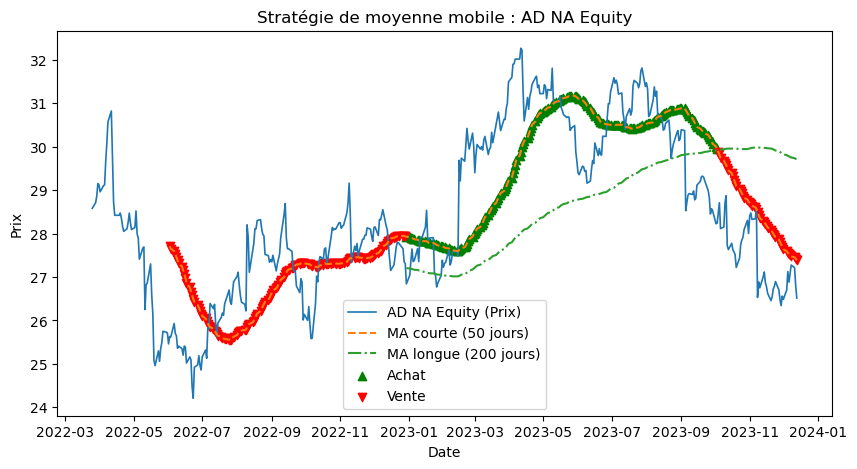

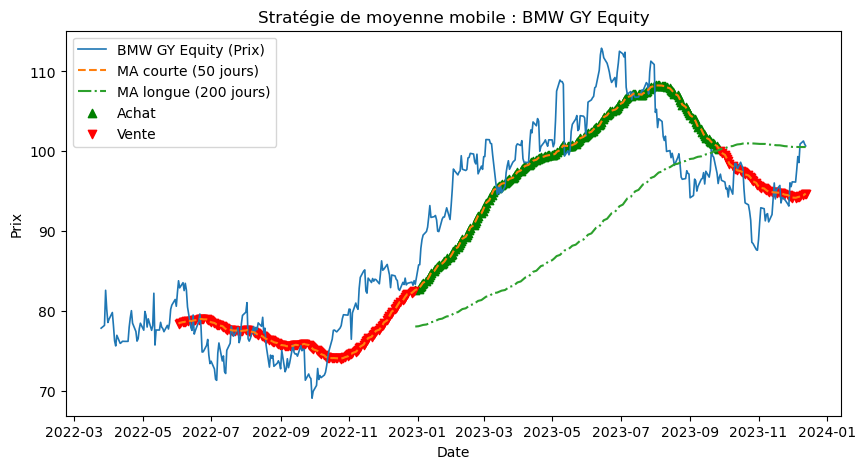

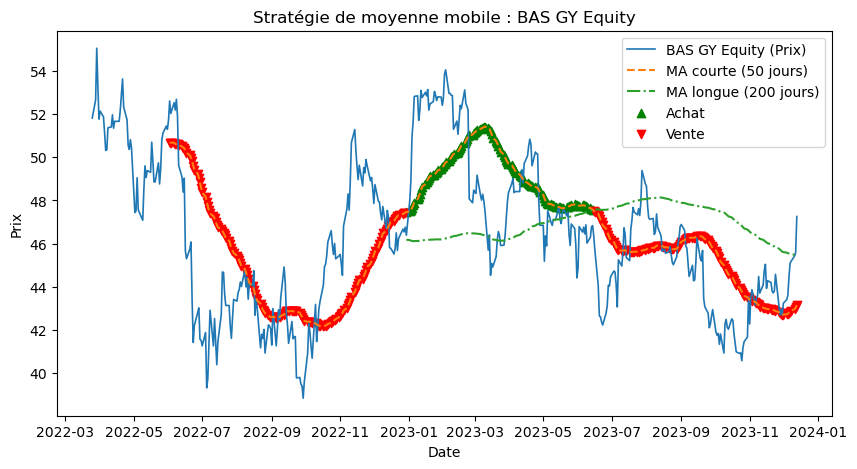

In [165]:
# Paramètres des moyennes mobiles
short_window = 50  # Fenêtre pour la moyenne mobile courte (50 jours)
long_window = 200  # Fenêtre pour la moyenne mobile longue (200 jours)

# Calcul des moyennes mobiles et des signaux d'achat/vente
short_ma = df_simulation.rolling(window=short_window).mean()  # Calcul de la moyenne mobile courte
long_ma = df_simulation.rolling(window=long_window).mean()  # Calcul de la moyenne mobile longue
signals = (short_ma > long_ma).astype(int)  # Générer les signaux: 1 pour achat, 0 pour vente

# Sélectionner trois actions aléatoires pour les graphiques
selected_actions = random.sample(list(df_simulation.columns), 3)  # Choisir 3 actions aléatoires

# Calcul et affichage des graphiques pour chaque action sélectionnée
for action in selected_actions:
    plt.figure(figsize=(10, 5))  # Créer une nouvelle figure pour chaque graphique
    plt.plot(df_simulation[action], label=f'{action} (Prix)', linewidth=1.2)  # Tracer les prix de l'action
    plt.plot(short_ma[action], label=f'MA courte ({short_window} jours)', linestyle='--')  # Tracer la moyenne mobile courte
    plt.plot(long_ma[action], label=f'MA longue ({long_window} jours)', linestyle='-.')  # Tracer la moyenne mobile longue
    plt.scatter(df_simulation.index[signals[action] == 1], short_ma[action][signals[action] == 1], color='g', marker='^', label='Achat')  # Signaux d'achat (vert)
    plt.scatter(df_simulation.index[signals[action] == 0], short_ma[action][signals[action] == 0], color='r', marker='v', label='Vente')  # Signaux de vente (rouge)
    plt.title(f"Stratégie de moyenne mobile : {action}")  # Titre du graphique
    plt.xlabel("Date")  # Légende de l'axe des X
    plt.ylabel("Prix")  # Légende de l'axe des Y
    plt.legend()  # Ajouter une légende
    plt.show()  # Afficher le graphique

# Filtrer les signaux en ignorant les 200 premiers jours (phase d'apprentissage)
df_results = signals.iloc[200:]  # Prendre les données à partir du 201ème jour
df_results.columns = [col.replace('_Signal', '') for col in df_results.columns]  # Renommer les colonnes pour enlever '_Signal'


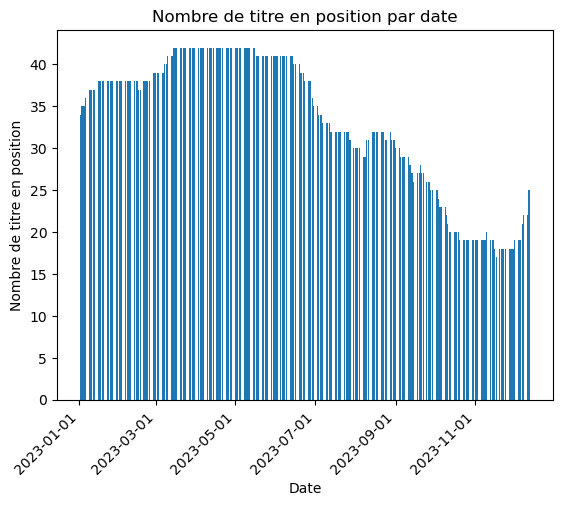

248

In [166]:
# Contrôle condition
df_check = pd.DataFrame({'NB_POS': df_results.sum(axis=1)})

# Visualisation graphique
from matplotlib.dates import DateFormatter

fig, ax = plt.subplots()
bars = ax.bar(df_check.index, df_check['NB_POS'])

# Incliner les étiquettes d'axe pour une meilleure lisibilité
ax.xaxis_date()
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Ajouter des étiquettes et un titre
plt.xlabel('Date')
plt.ylabel('Nombre de titre en position')
plt.title('Nombre de titre en position par date')

# Afficher le graphique
plt.show()

# Combien de dates ne respectent pas la condition
len(df_check[df_check == 0])

In [167]:
# Ajout de la colonne des besoins de l'EURIBOR 6M
df_check['EUR006M Index'] = df_check['NB_POS'].apply(lambda x: 0 if x > 0 else 1)

# Jointure de la selection des actions avec la colonne des moments où la sélection a été trop sélectif
final_selection = pd.merge(df_results, df_check['EUR006M Index'], on='Date')
final_selection

,ADS GY Equity,AI FP Equity,AIR FP Equity,ALV GY Equity,ABI BB Equity,ASML NA Equity,CS FP Equity,BBVA SM Equity,SAN SM Equity,BAS GY Equity,...,RI FP Equity,SAF FP Equity,SAN FP Equity,SAP GY Equity,SU FP Equity,SIE GY Equity,TTE FP Equity,DG FP Equity,VOW3 GY Equity,EUR006M Index
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-02,0,1,1,1,1,1,1,1,1,1,...,0,1,0,1,1,1,1,1,0,0
2023-01-03,0,1,1,1,1,1,1,1,1,1,...,0,1,0,1,1,1,1,1,0,0
2023-01-04,0,1,1,1,1,1,1,1,1,1,...,0,1,0,1,1,1,1,1,0,0
2023-01-05,0,1,1,1,1,1,1,1,1,1,...,0,1,0,1,1,1,1,1,0,0
2023-01-06,0,1,1,1,1,1,1,1,1,1,...,0,1,0,1,1,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-07,1,1,1,1,0,0,1,1,1,0,...,0,1,0,1,0,0,1,0,0,0
2023-12-08,1,1,1,1,0,0,1,1,1,0,...,0,1,0,1,0,0,1,1,0,0
2023-12-11,1,1,1,1,0,0,1,1,1,0,...,0,1,0,1,0,0,1,1,0,0


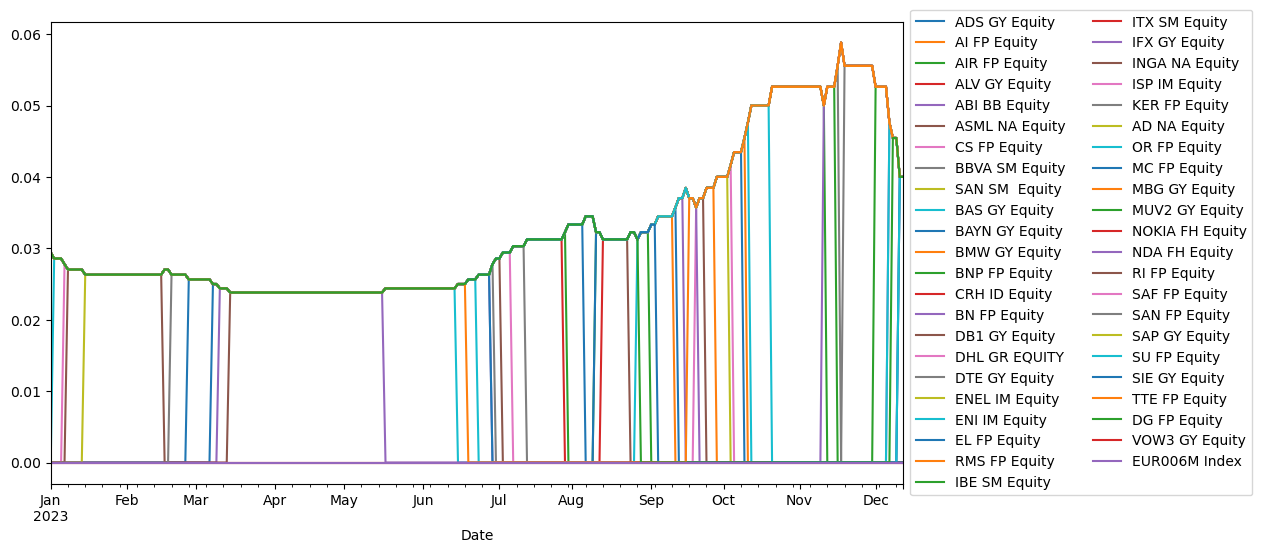

In [168]:
# Ensuite nettoyage du jeu de données 
# la méthode fillna(0) pour remplacer les NaN résultant des valeurs non remplacées par des zéros.
weights = final_selection.fillna(0)

# Calcul des allocations 
# la dernière étape calcule les poids normalisés pour chaque ligne.
weights = weights.apply(lambda x: x / x.sum(), axis=1) 

# Plot avec légende à droite du graphique
ax = weights.plot(figsize=(11, 6))
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2)  # Légende sur deux colonnes

plt.show()

In [169]:
# calculer les rentabilités journalières
daily_returns = df_simulation.pct_change(periods=1).dropna()

# nous nous assurons que les dataframes soient bien triés
daily_returns.sort_index(ascending=True, inplace=True)
weights.sort_index(ascending=True, inplace=True)

# Nous devons joindre les données daily_euribor avec les daily_returns
final_returns = pd.merge(daily_returns, daily_Euribor, on='Date')

# on s'assure que le dataframe Weight fait la bonne taille
final_returns = final_returns.loc[final_selection.index[0]:final_selection.index[-1]]
weights = weights.loc[final_selection.index[0]:final_selection.index[-1]]

# Nous multiplions les poids journaliers par les rendements journaliers ainsi nous obtenons les contributions à la performance
strategy_returns = final_returns * weights

# la méthode fillna(0) pour remplacer les NaN résultant des valeurs non remplacées par des zéros.
strategy_returns = strategy_returns.fillna(0)

# La somme des contributions à la performance des actions allouées donne la contribution journalière de la position  
strategy_returns = strategy_returns.sum(axis=1)

strategy_returns.iloc[0] = 0 # nous forçons les premières contributions à la performance à 0 (le premier jour nous ne profitons pas de la performance du jour)

# Calcul des performances cumulées
cumulative_return = pd.DataFrame((1 + strategy_returns).cumprod()*100, columns = ['MM'])

print(cumulative_return)


                    MM
Date                  
2023-01-02  100.000000
2023-01-03  100.733569
2023-01-04  103.252616
2023-01-05  103.268079
2023-01-06  104.618357
...                ...
2023-12-07  116.623326
2023-12-08  117.595685
2023-12-11  117.872630
2023-12-12  117.844393
2023-12-13  117.904150

[248 rows x 1 columns]


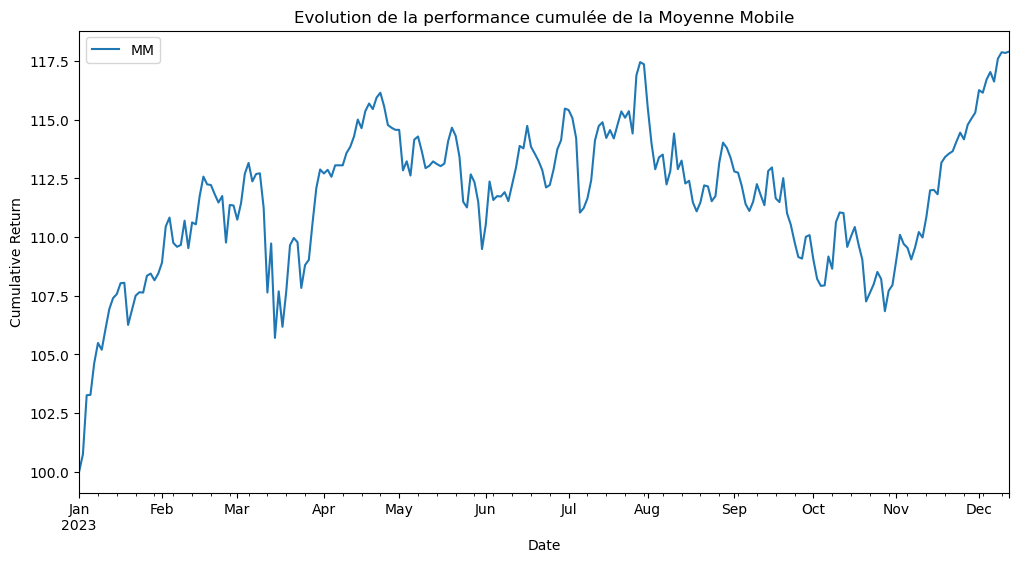

In [170]:
# graphique de l'évolution de la performance cumulée
cumulative_return.plot(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Evolution de la performance cumulée de la Moyenne Mobile")
plt.show()

### 3) Comparaison avec le benchmark (SX5E)

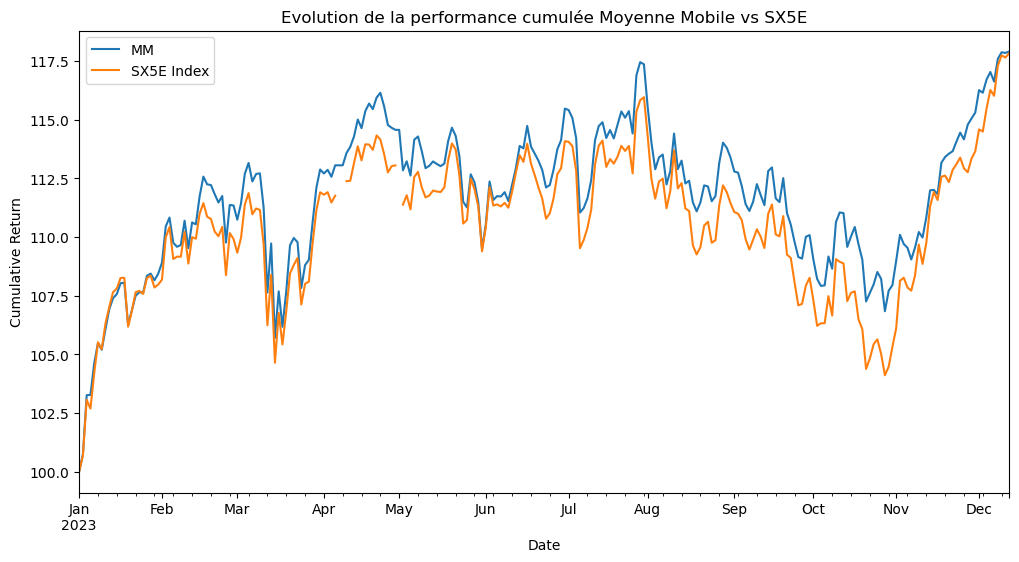

In [173]:
df = pd.read_csv("eurostoxx50_data.csv", sep=';', index_col = 'Date', date_parser=lambda x: pd.to_datetime(x, format='%d/%m/%Y'))
df = df.applymap(lambda x: pd.to_numeric(x.replace(",", "."), errors='coerce'))

# Calcul des rentabilités journalières de l'Eurostoxx 50
daily_returns_SX5E = df.pct_change().fillna(0)

# Restriction des données à la période d'intérêt
daily_returns_SX5E = daily_returns_SX5E.loc[final_returns.index]

# Forcer la première valeur de rentabilité journalière à 0
daily_returns_SX5E.iloc[0] = 0

# Calcul de la performance cumulée de l'Eurostoxx 50
cumulative_return_SX5E = (1 + daily_returns_SX5E).cumprod() * 100

# Création d'un dataframe contenant les 2 valeurs
Compare = cumulative_return.join(cumulative_return_SX5E)

# graphique de l'évolution de la performance cumulée du SX5E
Compare.plot(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Evolution de la performance cumulée Moyenne Mobile vs SX5E")
plt.show()


En analysant la performance de la stratégie de moyenne mobile par rapport à l'indice **SX5E**, voici les principales observations :

La stratégie MM suit une trajectoire relativement proche de l'indice SX5E pendant la majeure partie de l'année.
Quelques périodes de divergence sont visibles, notamment dans les phases où la stratégie MM semble légèrement surperformer (par exemple, au début de l'année et en décembre).

#### **1. Début janvier 2023 : Sous-performance initiale**
- Pendant les premières semaines de **janvier 2023**, la courbe **SX5E (orange)** est au-dessus de la courbe de la stratégie **moyenne mobile (bleu)**.
- Cela indique une **sous-performance initiale** de la stratégie, probablement liée à une moindre réactivité aux premiers mouvements de l'année.

#### **2. Mi-janvier 2023 : Début de la surperformance**
- À partir de **mi-janvier**, la stratégie commence à **surperformer légèrement l'indice**.
- Cette surperformance reste **modeste**, mais elle montre que la stratégie commence à mieux capter les tendances positives du marché.
- Pendant les phases de baisse (par exemple, en août-septembre), la stratégie MM semble mieux limiter les pertes par rapport à l'indice SX5E. Cela confirme que les croisements des moyennes mobiles offrent une certaine protection contre les baisses, bien que cela dépende du timing.
- À la fin de l'année, la stratégie MM surpasse l'indice, probablement en captant une tendance haussière plus tôt que l'indice.
  
### Conclusion finale

- **Début janvier 2023** : Sous-performance initiale.
- **Mi-janvier à décembre 2023** : Surperformance légère mais intermittente, avec des phases de parité.


La stratégie de moyenne mobile montre une **forte efficacité dans les tendances haussières prolongées**, mais pourrait être améliorée pour mieux gérer les périodes de **volatilité** ou de **retournements rapides**.


## D - Ouverture



En analysant les performances de la stratégie de **moyenne mobile**, voici une ouverture sur d'autres stratégies d'investissement possibles et leurs spécificités.

### Avantages et Inconvénients de la Moyenne Mobile

#### **Avantages**
1. **Simplicité** :
   - Facile à comprendre et à implémenter.
   - Peu coûteux en termes de calcul.
2. **Adaptabilité** :
   - Fonctionne bien dans les marchés **trending** (avec des tendances nettes).
3. **Réactivité** :
   - Les signaux sont générés rapidement dans des environnements de tendance stable.

#### **Inconvénients**
1. **Moins performant en marchés volatils** :
   - Lors de retournements brusques, la stratégie peut donner des signaux tardifs.
2. **Faux signaux** :
   - Problème des **"whipsaws"** : des entrées et sorties fréquentes en l'absence de tendance claire.
3. **Absence d'optimisation du risque** :
   - Contrairement à d'autres approches, elle ne prend pas en compte la **volatilité** ou la **corrélation des actifs**.

### Suggestions pour améliorer l'analyse et la stratégie
1. Ajout d'une métrique de performance
Inclure des indicateurs comme :
- Ratio de Sharpe : Pour mesurer le rendement ajusté au risque.
- Drawdown maximal : Pour évaluer la pire perte cumulée.
- Volatilité annualisée : Pour comparer le risque pris par rapport à l'indice SX5E

2. Séparer les performances par année (2019, 2020, etc.) pour voir dans quelles conditions la stratégie est la plus efficace
3. Tester des fenêtres alternatives pour les moyennes mobiles (par exemple, 20 et 100 jours au lieu de 50 et 200) pour voir si cela améliore les performances
4. Identifier les périodes où la stratégie MM a donné des signaux d'achat ou de vente, mais où ces signaux n'ont pas été bénéfiques (marchés latéraux ou bruit)
5. Utiliser des moyennes mobiles adaptatives qui ajustent leurs périodes en fonction de la volatilité ou d'autres indicateurs de marché.
6. Ajouter une condition pour que les croisements doivent être maintenus pendant un certain nombre de jours avant de valider un signal.
7. Intégrer une gestion des positions basée sur le risque, en ajustant la taille des positions selon la volatilité (ex. méthode ATR – Average True Range).
8. Ajouter des instruments de couverture comme des options ou des ETFs pour protéger le portefeuille.
9. Tester la stratégie sur des données remontant à 2008 (pour inclure une crise majeure comme celle des subprimes) et inclure des périodes de crise (ex. COVID-19).
10. Utiliser des modèles supervisés pour prédire les tendances en combinant les croisements de moyennes mobiles avec d'autres indicateurs.




### Stratégies Alternatives possibles

#### **Théorie de Markowitz (Optimisation de Portefeuille)**
1. **Concept** :
   - La stratégie repose sur la diversification des actifs pour **maximiser le rendement attendu** tout en **minimisant le risque**.
   - Elle s'appuie sur la matrice de covariance des actifs pour optimiser le portefeuille.

2. **Avantages** :
   - **Approche scientifique** : Base mathématique solide (variance et rendement attendu).
   - **Réduction des risques** : Prend en compte la corrélation entre les actifs.
   - Bien adaptée pour des portefeuilles à long terme.

3. **Inconvénients** :
   - Sensible aux **hypothèses des données d'entrée** (rendements et corrélations prévus).
   - **Complexité** : Requiert plus de calculs et de données historiques.
   - Moins réactif aux fluctuations du marché à court terme.

#### **Autres stratégies possibles**
1. **Momentum** :
   - Acheter les actifs dont la tendance haussière est forte et vendre ceux en baisse.
   - Similaire à la moyenne mobile, mais peut inclure des critères plus complexes.
2. **Value Investing** :
   - Investir dans des actifs sous-évalués par rapport à leurs fondamentaux.
   - Long terme et moins sensible aux mouvements de marché immédiats.
3. **Arbitrage statistique** :
   - Exploiter les inefficiences du marché grâce à des modèles quantitatifs.

### Conclusion

- La **moyenne mobile** est une stratégie simple et efficace pour les tendances haussières, mais elle est vulnérable en cas de volatilité.
- En revanche, des stratégies comme celle de **Markowitz** permettent d'intégrer une gestion optimale des risques, bien que leur mise en œuvre soit plus complexe.
- Le choix de la stratégie dépendra des **objectifs de l'investisseur** (court terme ou long terme) et de son **appétence au risque**.


## Ouverture: l'exemple de la **stratégie de Markowitz**

<h2 style="padding:16px; color:#FFF; background:#800000"> Stratégie 2:  Théorie de Markowitz (Optimisation de Portefeuille)</h2>

La **théorie de Markowitz** optimise un portefeuille en maximisant le rendement attendu pour un risque donné ou en minimisant le risque pour un rendement donné. Elle repose sur la diversification des actifs et utilise des statistiques comme le rendement, la variance et la covariance.

#### Formulations Mathématiques

##### 1. Rendement attendu du portefeuille
$E(R_p) = \sum_{i=1}^n w_i E(R_i)$  
- $E(R_p)$ : Rendement attendu du portefeuille.  
- $w_i$ : Pondération de l'actif $i$.  
- $E(R_i)$ : Rendement attendu de l'actif $i$.  

##### 2. Variance (risque) du portefeuille
$\sigma_p^2 = \sum_{i=1}^n \sum_{j=1}^n w_i w_j \text{Cov}(R_i, R_j)$  
- $\sigma_p^2$ : Variance du portefeuille.  
- $\text{Cov}(R_i, R_j)$ : Covariance entre les actifs $i$ et $j$.  

##### 3. Optimisation
Trouver les $w_i$ qui minimisent :  
$\min \sigma_p^2 \quad \text{sous la contrainte} \quad \sum_{i=1}^n w_i = 1$

#### Frontière Efficiente
La **frontière efficiente** est l'ensemble des portefeuilles offrant :  
- Le meilleur rendement pour un risque donné.  
- Le risque minimal pour un rendement fixé.  

#### Diversification
- La diversification réduit le risque global si les actifs ne sont pas parfaitement corrélés ($\rho < 1$).  
- En combinant des actifs avec des rendements faiblement corrélés, la volatilité du portefeuille est atténuée.  

#### Avantages et Limites

##### Avantages
- Réduction du risque grâce à la diversification.  
- Approche scientifique et rigoureuse.  

##### Limites
- Hypothèses simplificatrices (données historiques, rendements normaux).  
- Néglige les coûts de transaction et les contraintes de marché.  

#### Conclusion
La théorie de Markowitz pose les bases de l'optimisation de portefeuille, en combinant mathématiques et gestion de risques. Elle reste un pilier fondamental de la finance moderne.


Portefeuille optimal:
Rendement attendu: 0.05%
Volatilité (écart-type): 1.55%
Ratio de Sharpe: -0.61
Poids des actions dans le portefeuille optimal:
ADS GY Equity: 2.12%
AI FP Equity: 2.88%
AIR FP Equity: 1.18%
ALV GY Equity: 2.85%
ABI BB Equity: 3.02%
ASML NA Equity: 3.69%
CS FP Equity: 2.63%
BBVA SM Equity: 4.14%
SAN SM  Equity: 1.10%
BAS GY Equity: 1.87%
BAYN GY Equity: 0.31%
BMW GY Equity: 2.57%
BNP FP Equity: 3.67%
CRH ID Equity: 1.46%
BN FP Equity: 0.87%
DB1 GY Equity: 1.91%
DHL GR EQUITY: 0.24%
DTE GY Equity: 2.05%
ENEL IM Equity: 1.61%
ENI IM Equity: 0.03%
EL FP Equity: 1.69%
RMS FP Equity: 4.28%
IBE SM Equity: 2.91%
ITX SM Equity: 0.04%
IFX GY Equity: 4.09%
INGA NA Equity: 3.87%
ISP IM Equity: 3.41%
KER FP Equity: 3.33%
AD NA Equity: 0.27%
OR FP Equity: 1.96%
MC FP Equity: 2.55%
MBG GY Equity: 4.23%
MUV2 GY Equity: 3.18%
NOKIA FH Equity: 3.29%
NDA FH Equity: 1.08%
RI FP Equity: 0.59%
SAF FP Equity: 4.24%
SAN FP Equity: 1.27%
SAP GY Equity: 1.72%
SU FP Equity: 1.86%
SIE GY Equi

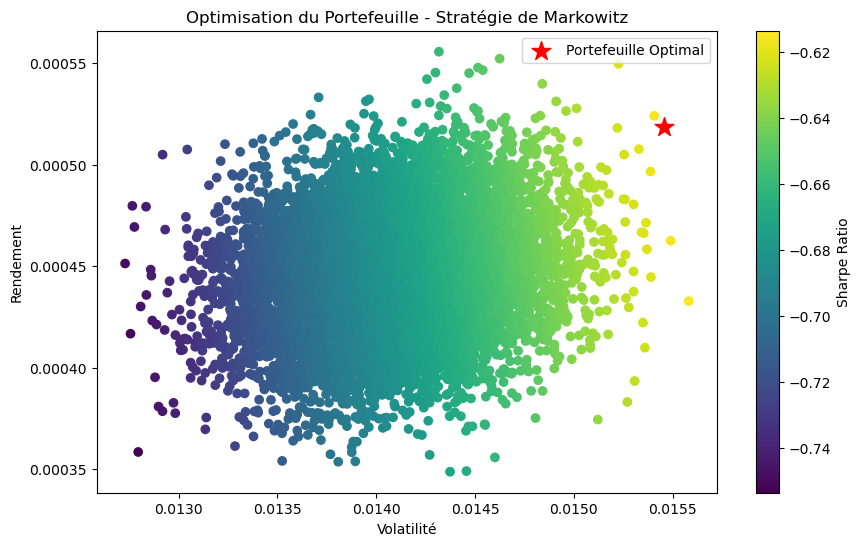

In [180]:
# Chargement des données depuis le fichier CSV
df = pd.read_csv("compo_eurostoxx_data.csv", sep=';', index_col='Date', parse_dates=['Date'], date_format='%d/%m/%Y')

# Conversion des virgules en points et transformation des données en numériques
df = df.apply(lambda col: col.apply(lambda x: pd.to_numeric(x.replace(",", "."), errors='coerce')) if col.dtype == 'object' else col)

# Plage de dates pour le backtesting
date_debut = '2018-12-31'
date_fin = '2022-12-30'

# Filtrage des données pour la plage de dates spécifiée
df_backtesting = df.loc[date_debut:date_fin]

# Calcul des rendements quotidiens
df_returns = df_backtesting.pct_change().dropna()

# Calcul de la moyenne des rendements et de la matrice de covariance des rendements
mean_returns = df_returns.mean()
cov_matrix = df_returns.cov()

# Paramètres de l'optimisation du portefeuille (Markowitz)
num_portfolios = 10000
risk_free_rate = 0.01

# Initialisation des listes pour les résultats
portfolio_returns = []
portfolio_volatility = []
portfolio_weights = []
portfolio_sharpe_ratio = []

# Simulation des portefeuilles
for _ in range(num_portfolios):
    # Générer des poids aléatoires pour chaque action
    weights = np.random.random(len(df_returns.columns))
    weights /= np.sum(weights)  # Normaliser pour que la somme des poids soit égale à 1
    
    # Calcul du rendement du portefeuille
    portfolio_return = np.sum(weights * mean_returns)
    portfolio_returns.append(portfolio_return)
    
    # Calcul de la volatilité du portefeuille (écart-type)
    portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
    portfolio_volatility.append(np.sqrt(portfolio_variance))
    
    # Calcul du ratio de Sharpe
    portfolio_sharpe = (portfolio_return - risk_free_rate) / np.sqrt(portfolio_variance)
    portfolio_sharpe_ratio.append(portfolio_sharpe)
    
    # Enregistrer les poids du portefeuille
    portfolio_weights.append(weights)

# Convertir les résultats en DataFrame
portfolio_data = {
    'Returns': portfolio_returns,
    'Volatility': portfolio_volatility,
    'Sharpe Ratio': portfolio_sharpe_ratio
}

for i, symbol in enumerate(df_returns.columns):
    portfolio_data[symbol] = [weights[i] for weights in portfolio_weights]

df_portfolios = pd.DataFrame(portfolio_data)

# Trouver le portefeuille optimal (celui avec le meilleur Sharpe ratio)
max_sharpe_idx = df_portfolios['Sharpe Ratio'].idxmax()
optimal_portfolio = df_portfolios.iloc[max_sharpe_idx]

# Affichage du portefeuille optimal
print("Portefeuille optimal:")
print(f"Rendement attendu: {optimal_portfolio['Returns']:.2%}")
print(f"Volatilité (écart-type): {optimal_portfolio['Volatility']:.2%}")
print(f"Ratio de Sharpe: {optimal_portfolio['Sharpe Ratio']:.2f}")
print("Poids des actions dans le portefeuille optimal:")
for symbol, weight in zip(df_returns.columns, optimal_portfolio[df_returns.columns]):
    print(f"{symbol}: {weight:.2%}")

# Visualisation des résultats
plt.figure(figsize=(10, 6))
plt.scatter(df_portfolios['Volatility'], df_portfolios['Returns'], c=df_portfolios['Sharpe Ratio'], cmap='viridis')
plt.colorbar(label='Sharpe Ratio')
plt.scatter(optimal_portfolio['Volatility'], optimal_portfolio['Returns'], color='red', marker='*', s=200, label='Portefeuille Optimal')
plt.title('Optimisation du Portefeuille - Stratégie de Markowitz')
plt.xlabel('Volatilité')
plt.ylabel('Rendement')
plt.legend(loc='best')
plt.show()

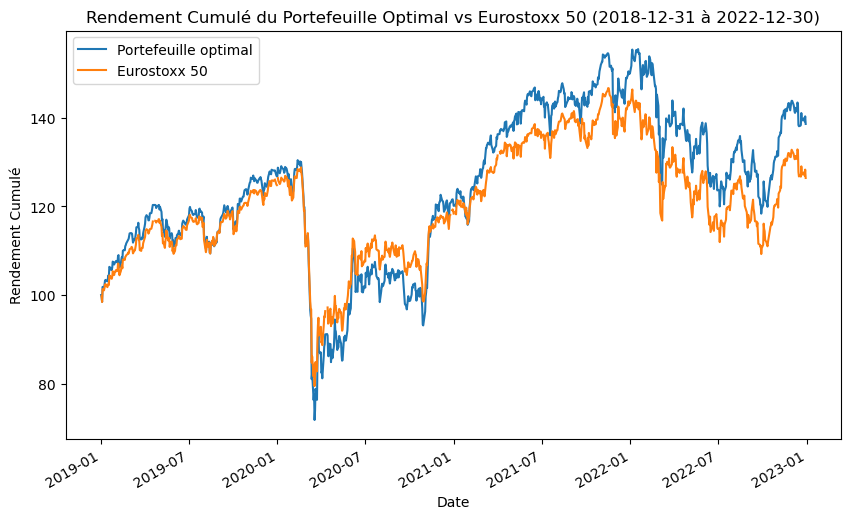

In [183]:
# Chargement des données depuis le fichier CSV
df = pd.read_csv("compo_eurostoxx_data.csv", sep=';', index_col='Date', parse_dates=['Date'], date_format='%d/%m/%Y')

# Conversion des virgules en points et transformation des données en numériques
df = df.apply(lambda col: col.apply(lambda x: pd.to_numeric(x.replace(",", "."), errors='coerce')) if col.dtype == 'object' else col)

# Plage de dates pour la période 2018-12-31 à 2022-12-30
date_debut = '2018-12-31'
date_fin = '2022-12-30'

# Filtrage des données pour la période spécifiée
df_backtesting = df.loc[date_debut:date_fin]

# Calcul des rendements quotidiens
df_returns = df_backtesting.pct_change().dropna()

# Calcul de la moyenne des rendements et de la matrice de covariance des rendements
mean_returns = df_returns.mean()
cov_matrix = df_returns.cov()

# Paramètres de l'optimisation du portefeuille (Markowitz)
num_portfolios = 10000
risk_free_rate = 0.01

# Initialisation des listes pour les résultats
portfolio_returns = []
portfolio_volatility = []
portfolio_weights = []
portfolio_sharpe_ratio = []

# Simulation des portefeuilles pour la période spécifiée
for _ in range(num_portfolios):
    # Générer des poids aléatoires pour chaque action
    weights = np.random.random(len(df_returns.columns))
    weights /= np.sum(weights)  # Normaliser pour que la somme des poids soit égale à 1
    
    # Calcul du rendement du portefeuille
    portfolio_return = np.sum(weights * mean_returns)
    portfolio_returns.append(portfolio_return)
    
    # Calcul de la volatilité du portefeuille (écart-type)
    portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
    portfolio_volatility.append(np.sqrt(portfolio_variance))
    
    # Calcul du ratio de Sharpe
    portfolio_sharpe = (portfolio_return - risk_free_rate) / np.sqrt(portfolio_variance)
    portfolio_sharpe_ratio.append(portfolio_sharpe)
    
    # Enregistrer les poids du portefeuille
    portfolio_weights.append(weights)

# Convertir les résultats en DataFrame
portfolio_data = {
    'Returns': portfolio_returns,
    'Volatility': portfolio_volatility,
    'Sharpe Ratio': portfolio_sharpe_ratio
}

for i, symbol in enumerate(df_returns.columns):
    portfolio_data[symbol] = [weights[i] for weights in portfolio_weights]

df_portfolios = pd.DataFrame(portfolio_data)

# Calcul du portefeuille optimal basé sur le Sharpe Ratio maximum
max_sharpe_idx = df_portfolios['Sharpe Ratio'].idxmax()
optimal_portfolio = df_portfolios.iloc[max_sharpe_idx]

# Récupérer les poids optimaux
optimal_weights = optimal_portfolio[df_returns.columns]

# Calcul des rendements cumulés du portefeuille optimal
df_cumulative_returns = (1 + df_returns.dot(optimal_portfolio[df_returns.columns])).cumprod()
df_cumulative_returns = df_cumulative_returns*100

# Calcul de la performance cumulée de l'Eurostoxx 50 pour comparaison
# Charger les données de l'Eurostoxx 50 (assurez-vous que ce fichier est disponible)
df_eurostoxx = pd.read_csv("eurostoxx50_data.csv", sep=';', index_col='Date', parse_dates=['Date'], date_format='%d/%m/%Y')

# Conversion des virgules en points et transformation des données en numériques
df_eurostoxx = df_eurostoxx.apply(lambda col: col.apply(lambda x: pd.to_numeric(x.replace(",", "."), errors='coerce')) if col.dtype == 'object' else col)

# Filtrer les données pour la période de 2018-12-31 à 2022-12-30
df_eurostoxx = df_eurostoxx.loc[date_debut:date_fin]

# Calcul des rendements quotidiens de l'Eurostoxx 50
daily_returns_SX5E = df_eurostoxx.pct_change().dropna()

# Calcul de la performance cumulée de l'Eurostoxx 50
cumulative_return_SX5E = (1 + daily_returns_SX5E).cumprod() * 100

# Créer un DataFrame avec les rendements cumulés du portefeuille optimal et de l'Eurostoxx 50
df_cumulative_returns = pd.DataFrame(df_cumulative_returns, columns=['Portefeuille optimal'])
df_cumulative_returns['Eurostoxx 50'] = cumulative_return_SX5E

# Visualisation des rendements cumulés
fig, ax = plt.subplots(figsize=(10, 6))
df_cumulative_returns.plot(ax=ax)
ax.set_title("Rendement Cumulé du Portefeuille Optimal vs Eurostoxx 50 (2018-12-31 à 2022-12-30)")
ax.set_xlabel("Date")
ax.set_ylabel("Rendement Cumulé")
plt.legend(loc='upper left')
plt.show()


### Analyse de la Performance

Le portefeuille optimal surpasse l'indice **Eurostoxx 50** sur la période du **21/12/2018 au 30/12/2022** en termes de rendement cumulé **sauf durant l'année 2020** où l'on observe une sous-performance. Nous constatons que cette surperformance est particulièrement notable lors des périodes de hausse.

En résumé, le portefeuille optimal démontre une **meilleure performance globale**, confirmant l'efficacité de l'optimisation pour générer un rendement supérieur à celui de l'indice de marché.

## **Simulation: sur l'année 2023**

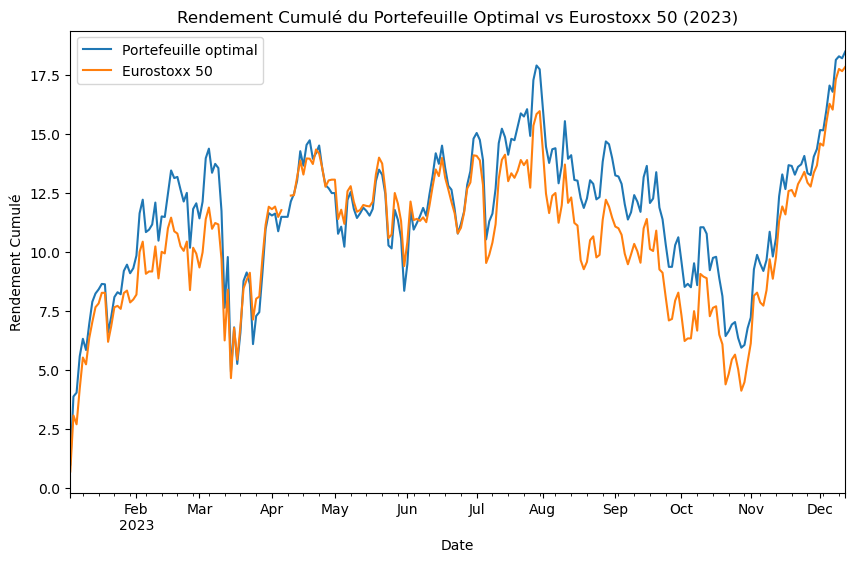

In [202]:
# Chargement des données depuis le fichier CSV
df = pd.read_csv("compo_eurostoxx_data.csv", sep=';', index_col='Date', parse_dates=['Date'], date_format='%d/%m/%Y')

# Conversion des virgules en points et transformation des données en numériques
df = df.apply(lambda col: col.apply(lambda x: pd.to_numeric(x.replace(",", "."), errors='coerce')) if col.dtype == 'object' else col)

# Filtrage des données pour la période de 2023 uniquement
df_2023 = df.loc['2023-01-01':'2023-12-31']

# Calcul des rendements quotidiens de l'Eurostoxx 50 pour 2023
df_returns_2023 = df_2023.pct_change().dropna()

# Calcul de la moyenne des rendements et de la matrice de covariance des rendements pour 2023
mean_returns_2023 = df_returns_2023.mean()
cov_matrix_2023 = df_returns_2023.cov()

# Paramètres de l'optimisation du portefeuille (Markowitz) pour 2023
num_portfolios = 10000
risk_free_rate = 0.01

# Initialisation des listes pour les résultats
portfolio_returns_2023 = []
portfolio_volatility_2023 = []
portfolio_weights_2023 = []
portfolio_sharpe_ratio_2023 = []

# Simulation des portefeuilles pour 2023
for _ in range(num_portfolios):
    # Générer des poids aléatoires pour chaque action
    weights = np.random.random(len(df_returns_2023.columns))
    weights /= np.sum(weights)  # Normaliser pour que la somme des poids soit égale à 1
    
    # Calcul du rendement du portefeuille
    portfolio_return = np.sum(weights * mean_returns_2023)
    portfolio_returns_2023.append(portfolio_return)
    
    # Calcul de la volatilité du portefeuille (écart-type)
    portfolio_variance = np.dot(weights.T, np.dot(cov_matrix_2023, weights))
    portfolio_volatility_2023.append(np.sqrt(portfolio_variance))
    
    # Calcul du ratio de Sharpe
    portfolio_sharpe = (portfolio_return - risk_free_rate) / np.sqrt(portfolio_variance)
    portfolio_sharpe_ratio_2023.append(portfolio_sharpe)
    
    # Enregistrer les poids du portefeuille
    portfolio_weights_2023.append(weights)

# Convertir les résultats en DataFrame
portfolio_data_2023 = {
    'Returns': portfolio_returns_2023,
    'Volatility': portfolio_volatility_2023,
    'Sharpe Ratio': portfolio_sharpe_ratio_2023
}

for i, symbol in enumerate(df_returns_2023.columns):
    portfolio_data_2023[symbol] = [weights[i] for weights in portfolio_weights_2023]

df_portfolios_2023 = pd.DataFrame(portfolio_data_2023)

# Trouver le portefeuille optimal (celui avec le meilleur Sharpe ratio) pour 2023
max_sharpe_idx_2023 = df_portfolios_2023['Sharpe Ratio'].idxmax()
optimal_portfolio_2023 = df_portfolios_2023.iloc[max_sharpe_idx_2023]

# Calcul des rendements cumulés du portefeuille optimal pour 2023
df_cumulative_returns_2023 = (1 + df_returns_2023.dot(optimal_portfolio_2023[df_returns_2023.columns])).cumprod() - 1
df_cumulative_returns_2023 *= 100  # Convertir en pourcentage

# Chargement des données Eurostoxx 50 pour la période de 2023
df_SX5E = pd.read_csv("eurostoxx50_data.csv", sep=';', index_col='Date', parse_dates=['Date'], date_format='%d/%m/%Y')

# Conversion des virgules en points et transformation des données en numériques
df_SX5E = df_SX5E.applymap(lambda x: pd.to_numeric(x.replace(",", "."), errors='coerce'))

# Calcul des rendements quotidiens de l'Eurostoxx 50 pour 2023
daily_returns_SX5E_2023 = df_SX5E.pct_change().fillna(0)
daily_returns_SX5E_2023 = daily_returns_SX5E_2023.loc['2023-01-01':'2023-12-31']

# Forcer la première valeur de rentabilité journalière à 0
daily_returns_SX5E_2023.iloc[0] = 0

# Calcul de la performance cumulée de l'Eurostoxx 50 pour 2023
cumulative_return_SX5E_2023 = (1 + daily_returns_SX5E_2023).cumprod() - 1
cumulative_return_SX5E_2023 *= 100  # Convertir en pourcentage

# Création d'un DataFrame pour comparer les rendements cumulés du portefeuille optimal et de l'Eurostoxx 50
df_cumulative_returns_comparison_2023 = pd.DataFrame(df_cumulative_returns_2023, columns=['Portefeuille optimal'])
df_cumulative_returns_comparison_2023['Eurostoxx 50'] = cumulative_return_SX5E_2023

# Visualisation
fig, ax = plt.subplots(figsize=(10, 6))
df_cumulative_returns_comparison_2023.plot(ax=ax)
ax.set_title("Rendement Cumulé du Portefeuille Optimal vs Eurostoxx 50 (2023)")
ax.set_xlabel("Date")
ax.set_ylabel("Rendement Cumulé")
plt.legend(loc='upper left')
plt.show()


### Analyse de la Performance

Le portefeuille optimal surpasse globalement l'indice **Eurostoxx 50** en termes de rendement cumulé tout au **long de l'année 2023 sauf de mi mars à début juin** où l'on observe une sous-performance. En termes de chiffres:

- À la **fin de l'année**, le portefeuille optimal affiche un rendement cumulé d'environ **18%**, contre **17,5%** pour l'Eurostoxx 50.

En résumé, le portefeuille optimal démontre une **meilleure performance globale**, confirmant l'efficacité de l'optimisation pour générer un rendement supérieur à celui de l'indice de marché.

**FIN DE PROJET**